Lets now use out model to predict stabilizing candidates for a given protein sequence.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.features import get_wt_seq


X_df = pd.read_pickle('../data/processed/X_df.pkl')
X_df = get_wt_seq(X_df)
y_df = pd.read_pickle('../data/processed/y_df.pkl')

## Create new dataset
finetune_df = X_df[['WT_name', 'wt_aa_seq', 'aa_seq', 'position']].copy()
finetune_df["ddG"] = y_df.to_numpy()
finetune_df.head()

In [16]:
from sklearn.model_selection import GroupShuffleSplit

groups = finetune_df["WT_name"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

## Get the trainval and test dataset
trainval_idx, test_idx = next(splitter.split(finetune_df, groups=groups))

trainval_df = finetune_df.iloc[trainval_idx].copy()
test_df = finetune_df.iloc[test_idx].copy()


## Split the trainval dataset into train and valdiate
groups = trainval_df["WT_name"]
train_idx, val_idx = next(splitter.split(trainval_df, groups=groups))

train_df = trainval_df.iloc[train_idx].copy()
val_df = trainval_df.iloc[val_idx].copy()

Grab a protein from the test set as the model will never have seen it before. Then use my  generate_single_mutants to create every possible mutant protein.

In [ ]:
test_df.head()

test_wt = test_df['wt_aa_seq'].iloc[0]
test_wt

from src.features import generate_single_mutants
test_seqs = generate_single_mutants(test_wt)
test_seqs

Now load in my trained model and predict ddG for all mutations to identify stabilizing ones. However, my generated squences do not have ddG values. Thus I need to go back and change several of my funcions and classes to accomodate this. Changed dataset class and collate function

In [ ]:
## Load in model
import torch

## Now we assemble the pieces of the model
from src.data import StabilityDataset
test_dataset = StabilityDataset(test_seqs) ## use test_seqs made above


## Use my computer's GPU over CPU for effiency
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

from transformers import AutoTokenizer, AutoModel
## Load ESM2 and define model and tokenizer
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)


## Initiate the collate function with the ESM-2 tokenizer that will be passed to the dataloader
from src.embeddings import make_collate_fn
collate_fn = make_collate_fn(tokenizer)

from src.models import ESMDeltaGRegressor
final_model = ESMDeltaGRegressor(
    esm_model=esm_model,
    embedding_dim=320,
    hidden_dim=128,
    dropout=0.2
)

from torch.utils.data import DataLoader
test_loader = DataLoader(
    StabilityDataset(test_seqs),
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn
)

## Now lets load in saved weights from notebook 4

## Get presaved weights
checkpoint_test = torch.load(
    "../data/processed/esm_finetuned_checkpoint.pt",
    map_location="cpu"
)

print(checkpoint_test.keys())
state_dict = checkpoint_test['model_state_dict']

final_model.load_state_dict(state_dict)
final_model = final_model.to(device)

final_model.eval()

In [20]:
## Evaluate the model on the generated test
from src.evaluate import evaluate_newdata
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

all_predictions = evaluate_newdata(test_loader, final_model, device)

Beautiful. Now Just need to add new column to my dataframe and then make some plots.

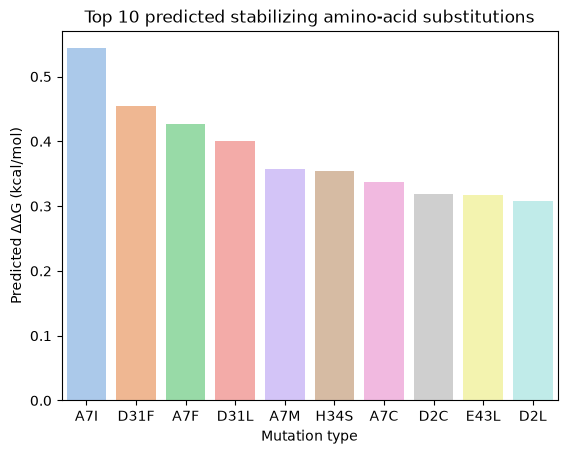

In [60]:
all_predictions.numpy()

test_seqs['predicted_ddG'] = all_predictions.numpy()
test_seqs

ranked_mutants = test_seqs.sort_values(
    "predicted_ddG",
    ascending=False
)
barplot = ranked_mutants[["mut_type", "predicted_ddG"]].head(10)

import seaborn as sns
sns.barplot(data = barplot, x = "mut_type", y = "predicted_ddG", hue = "mut_type", palette="pastel")
plt.xlabel('Mutation type')
plt.ylabel('Predicted ΔΔG (kcal/mol)')
plt.title('Top 10 predicted stabilizing amino-acid substitutions')
plt.savefig(
    "../figures/top10_stabilizing_subs.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Now draw some conclusions with ranked_mutants. How does mutant location affect sign of ddG?

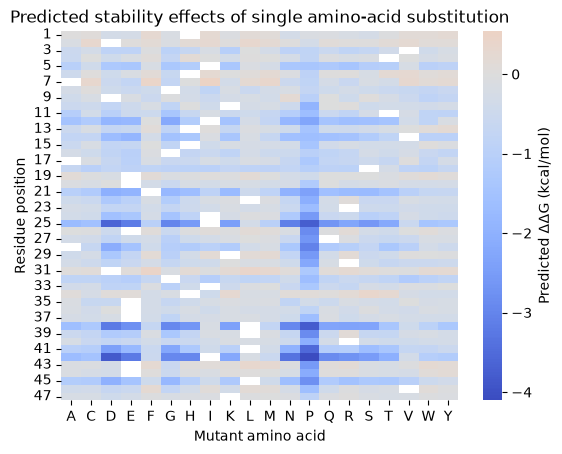

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

aa_length = len(ranked_mutants['wt_aa_seq'].iloc[0])

ranked_mutants['mut_aa'] = ranked_mutants['mut_type'].str.extract(r'^.*[0-9]+([A-Z]+)')


## pivot table to wide 

ranked_wide = ranked_mutants.pivot(index='position', columns='mut_aa', values='predicted_ddG')
ranked_wide
sns.heatmap(ranked_wide, cmap="coolwarm", center=0, cbar_kws={
        "label": "Predicted ΔΔG (kcal/mol)"})
plt.xlabel("Mutant amino acid")
plt.ylabel("Residue position")
plt.title("Predicted stability effects of single amino-acid substitution")
plt.savefig(
    "../figures/stability_pred_hm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

White squares represent the WT residue. We see some residue positions and specific substitutions have far more severe destabilizing predictions than others. Additionally it seems that mutations at the N- and C-terminus seemm to be less destabilizing than mutations in the middle of the sequence. 

Furthermore the Predicted ΔΔG is highly assymetric. As mentioned most residue mutations result in negative ΔΔG ranging from 0 to -5. However in the bar plot above, the most stabilizing mutation resulted in positive shift of 0.54. 

All this is inline with idea that proteins are evolved for stability, and similar to genes most mutations are deleterious (destabilizing).